# Seasonal Ensemble Analysis

Analyses of the WY2021 seasonal forcing ensemble across 8 domains and 22 domain/model combinations.

**Sections:**
1. Load all summary CSVs and engineer columns
2. Variability metrics: normality testing, CV vs. QCD, ranking water balance metrics by variability
3. ET and subsurface storage by climate condition (warm/cool × wet/dry)
4. Spatial discretization vs. subsurface representation: which drives more ensemble spread?
5. Fall and spring snow accumulation signal (positive SWE change as a predictor)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import product
import sys
sys.path.insert(0, '/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
from utils.custom import linear_reservoir

os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

DATA_DIR = Path('/scratch/dlhogan/ess-project-data')
SEASONS   = ['fall', 'winter', 'spring', 'summer']
TRANS_SEASONS = ['fall', 'spring']   # seasons of interest for snow/ET analyses

# Domain registry: spatial structure and available subsurface models
DOMAIN_REGISTRY = {
    'East_River_lumped':                    {'basin': 'East_River',    'spatial': 'lumped',      'models': ['bigBuckt', 'noXplict']},
    'East_River_distributed':               {'basin': 'East_River',    'spatial': 'elev',        'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'East_River_distributed_elevAspect':    {'basin': 'East_River',    'spatial': 'elevAspect',  'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'East_River_distributed_elevTPI':       {'basin': 'East_River',    'spatial': 'elevTPI',     'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'Tuolumne_River_lumped':                {'basin': 'Tuolumne_River','spatial': 'lumped',      'models': ['bigBuckt', 'noXplict']},
    'Tuolumne_River_distributed_elev':      {'basin': 'Tuolumne_River','spatial': 'elev',        'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'Tuolumne_River_distributed_elevAspect':{'basin': 'Tuolumne_River','spatial': 'elevAspect',  'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'Tuolumne_River_distributed_elevTPI':   {'basin': 'Tuolumne_River','spatial': 'elevTPI',     'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
}

SPATIAL_ORDER = ['lumped', 'elev', 'elevAspect', 'elevTPI']
MODEL_ORDER   = ['bigBuckt', 'noXplict', 'qTopmodl']
MODEL_COLORS  = {'bigBuckt': '#4878CF', 'noXplict': '#D65F5F', 'qTopmodl': '#6ACC65'}
BASIN_COLORS  = {'East_River': '#E07040', 'Tuolumne_River': '#7070CC'}

## 1. Load Summary CSVs

In [2]:
dfs = []
for domain, meta in DOMAIN_REGISTRY.items():
    ens_dir = DATA_DIR / f'domain_{domain}' / 'simulations' / 'seasonal_ensemble_simulations'
    for model in meta['models']:
        for season in SEASONS:
            csv = ens_dir / model / f'{season}_simulations' / 'summary.csv'
            if csv.exists():
                dfs.append(pd.read_csv(csv))

df = pd.concat(dfs, ignore_index=True)

# Engineer basin and spatial columns
df['basin']   = df['domain'].map({d: m['basin']   for d, m in DOMAIN_REGISTRY.items()})
df['spatial'] = df['domain'].map({d: m['spatial'] for d, m in DOMAIN_REGISTRY.items()})
df['spatial'] = pd.Categorical(df['spatial'], categories=SPATIAL_ORDER, ordered=True)
df['model']   = pd.Categorical(df['model'],   categories=MODEL_ORDER,   ordered=True)

print(f'Total rows: {len(df):,}')
print(f'Domains:    {df["domain"].nunique()}')
print(f'Models:     {df["model"].unique().tolist()}')
print(f'Seasons:    {df["season"].unique().tolist()}')
df.head(3)

Total rows: 1,760
Domains:    8
Models:     ['bigBuckt', 'noXplict', 'qTopmodl']
Seasons:    ['fall', 'winter', 'spring', 'summer']


,domain,model,season,donor_wy,total_q_mm,total_p_mm,runoff_ratio,total_et_sublim_mm,mean_aquifer_storage,mean_soil_liq_mm,mean_airtemp_C,total_snowfall_mm,pos_swe_change_mm,basin,spatial
0,East_River_lumped,bigBuckt,fall,2001,251.86,689.58,0.3652,377.22,0.1351,88.7477,2.033,445.72,338.85,East_River,lumped
1,East_River_lumped,bigBuckt,fall,2002,270.32,723.60,0.3736,382.04,0.1377,91.4362,2.529,472.26,356.33,East_River,lumped
2,East_River_lumped,bigBuckt,fall,2003,344.38,766.79,0.4491,386.49,0.1450,91.6478,2.119,514.74,407.15,East_River,lumped


## 2. Variability Metrics

First test normality (Shapiro-Wilk, n=20) per variable × season, then compute both parametric (CV) and non-parametric (QCD, NIQR, MAD) spread metrics across the 20 donor years.

| Metric | Formula | Notes |
|--------|---------|-------|
| CV | σ / μ | Parametric; assumes near-normal |
| QCD | (Q3−Q1)/(Q3+Q1) | Non-parametric analog to CV |
| NIQR | IQR / median | Simple; intuitive scale-free spread |
| MAD | median(\|xᵢ − median\|) | Most robust; not scale-free |

In [3]:
VARIABILITY_VARS = [
    ('total_q_mm',         'Total Q (mm)'),
    ('runoff_ratio',       'Runoff Ratio'),
    ('total_et_sublim_mm', 'ET + Sublim (mm)'),
    ('mean_soil_liq_mm',   'Mean Soil Liq (mm)'),
    ('mean_aquifer_storage','Mean Aquifer Storage (m)'),
    ('total_snowfall_mm',  'Total Snowfall (mm)'),
    ('pos_swe_change_mm',  'Positive SWE Change (mm)'),
]

def variability_metrics(x):
    """Compute variability metrics for a 1-D array x."""
    x = x.dropna()
    if len(x) < 4:
        return pd.Series({'n': len(x), 'cv': np.nan, 'qcd': np.nan,
                          'niqr': np.nan, 'mad': np.nan, 'sw_p': np.nan})
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    med = np.median(x)
    mu  = np.mean(x)
    sw_stat, sw_p = stats.shapiro(x)
    return pd.Series({
        'n'    : len(x),
        'mean' : mu,
        'cv'   : x.std() / mu if mu != 0 else np.nan,
        'qcd'  : (q3 - q1) / (q3 + q1) if (q3 + q1) != 0 else np.nan,
        'niqr' : iqr / med if med != 0 else np.nan,
        'mad'  : np.median(np.abs(x - med)),
        'sw_p' : sw_p,          # < 0.05 → reject normality
    })

rows = []
for varname, varlabel in VARIABILITY_VARS:
    if varname not in df.columns:
        continue
    for (basin, season, model), grp in df.groupby(['basin', 'season', 'model'], observed=True):
        m = variability_metrics(grp[varname])
        m['variable'] = varname
        m['label']    = varlabel
        m['basin']    = basin
        m['season']   = season
        m['model']    = model
        rows.append(m)

vm = pd.DataFrame(rows)
vm['normal'] = vm['sw_p'] > 0.05   # True = cannot reject normality
print(f'Fraction normally distributed (SW p>0.05): {vm["normal"].mean():.1%}')
print()
print('Normality by variable:')
vm.groupby('variable')['normal'].mean().sort_values().to_frame()

Fraction normally distributed (SW p>0.05): 32.1%

Normality by variable:


/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/hom

,normal
variable,
total_et_sublim_mm,0.000000
mean_soil_liq_mm,0.041667
runoff_ratio,0.250000
total_q_mm,0.375000
total_snowfall_mm,0.458333
pos_swe_change_mm,0.458333
mean_aquifer_storage,0.666667


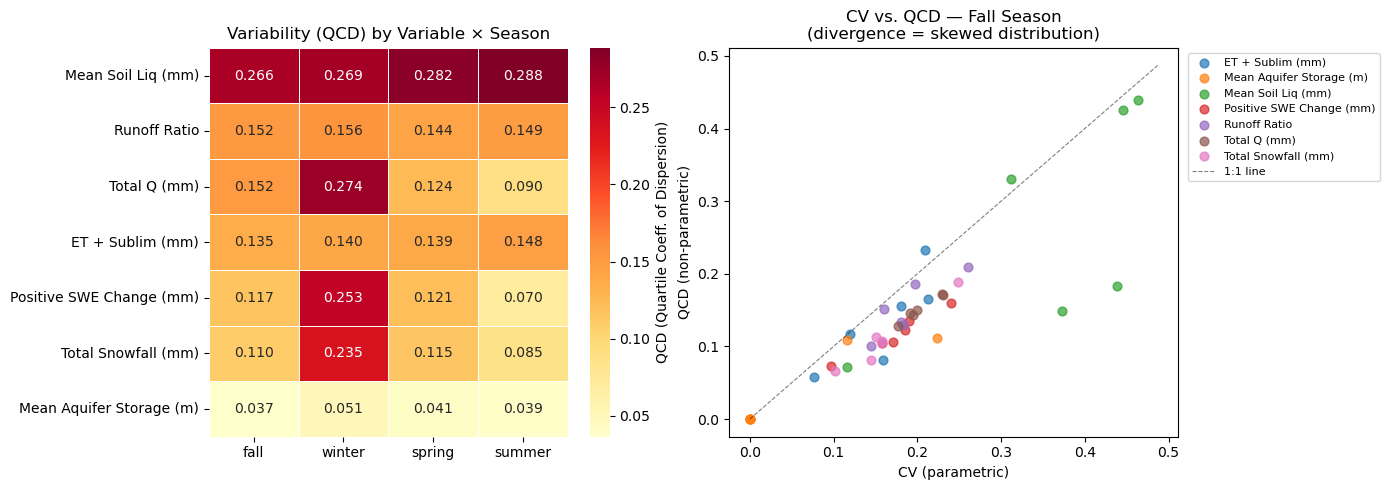

In [4]:
# Mean QCD per variable × season (averaged across domains/models)
qcd_pivot = (
    vm.groupby(['label', 'season'])['qcd']
    .mean()
    .unstack('season')[SEASONS]
    .sort_values('fall', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of QCD
sns.heatmap(
    qcd_pivot, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.3f',
    linewidths=0.5, cbar_kws={'label': 'QCD (Quartile Coeff. of Dispersion)'}
)
axes[0].set_title('Variability (QCD) by Variable × Season')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# CV vs QCD scatter — where they diverge, distribution is skewed
vm_fall = vm[vm['season'] == 'fall'].dropna(subset=['cv', 'qcd'])
for label, grp in vm_fall.groupby('label'):
    axes[1].scatter(grp['cv'], grp['qcd'], label=label, alpha=0.7, s=40)
lim = max(vm_fall[['cv','qcd']].max().max() * 1.05, 0.3)
axes[1].plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='1:1 line')
axes[1].set_xlabel('CV (parametric)')
axes[1].set_ylabel('QCD (non-parametric)')
axes[1].set_title('CV vs. QCD — Fall Season\n(divergence = skewed distribution)')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

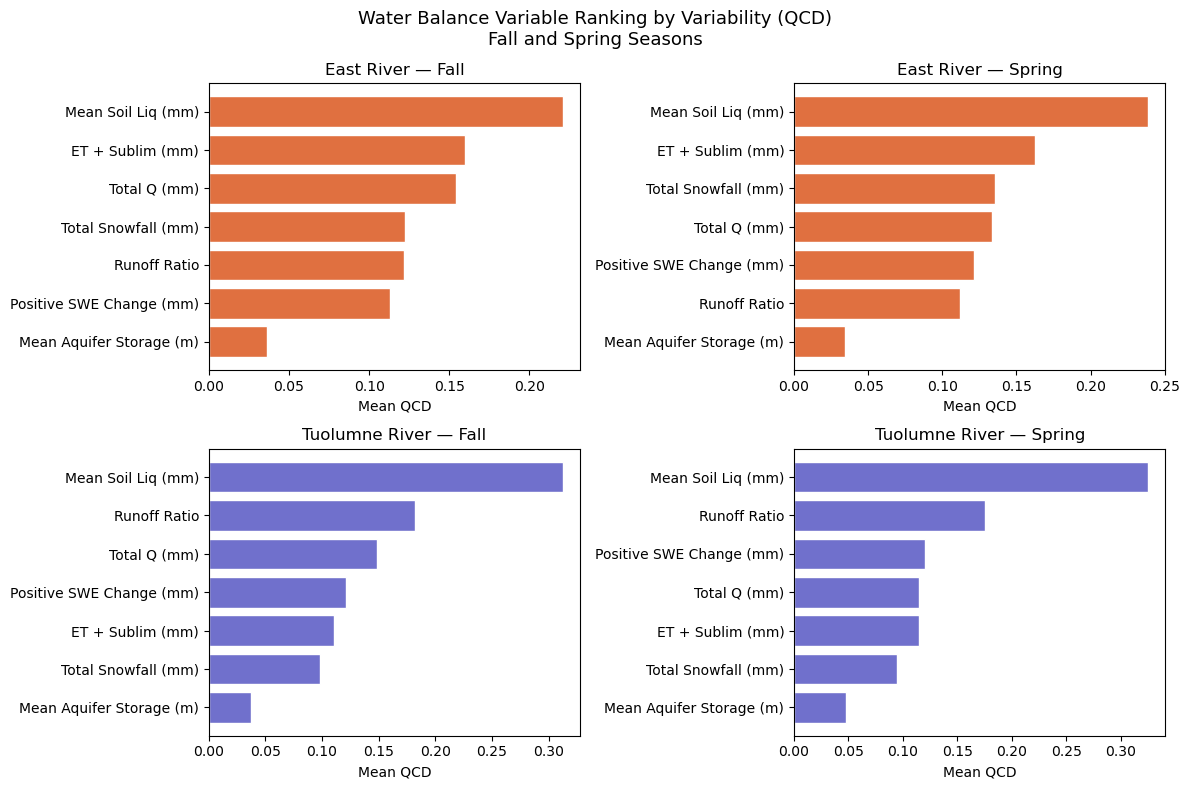

In [5]:
# Rank variables by QCD within each basin × season for fall and spring
rank_df = (
    vm[vm['season'].isin(TRANS_SEASONS)]
    .groupby(['basin', 'season', 'variable', 'label'])['qcd']
    .mean().reset_index()
    .sort_values(['basin', 'season', 'qcd'], ascending=[True, True, False])
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for ax, (basin, season) in zip(axes.flat, product(['East_River', 'Tuolumne_River'], TRANS_SEASONS)):
    sub = rank_df[(rank_df['basin'] == basin) & (rank_df['season'] == season)]
    ax.barh(sub['label'], sub['qcd'], color=BASIN_COLORS[basin], edgecolor='white')
    ax.set_xlabel('Mean QCD')
    ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
    ax.invert_yaxis()

plt.suptitle('Water Balance Variable Ranking by Variability (QCD)\nFall and Spring Seasons', fontsize=13)
plt.tight_layout()
plt.show()

## 3. ET and Subsurface Storage by Climate Condition

Classify each donor year within each basin × season group into four climate conditions using percentile-based thresholds:
- **Temperature**: `mean_airtemp_C` — < 25th = cool, > 75th = warm, otherwise normal  
- **Precipitation**: `total_p_mm` — < 25th = dry, > 75th = wet, otherwise normal  
- Labels: `warm-wet`, `warm-dry`, `cool-wet`, `cool-dry`, `normal` (middle 50th)

Classification uses thresholds from the forcing data embedded in each run (airtemp and pptrate stored in SUMMA output).

In [6]:
def classify_climate(grp, temp_col='mean_airtemp_C', ppt_col='total_p_mm'):
    """Assign warm/cool and wet/dry labels using 25th/75th percentile thresholds."""
    grp = grp.copy()
    t25, t75 = grp[temp_col].quantile([0.25, 0.75])
    p25, p75 = grp[ppt_col].quantile([0.25, 0.75])

    def label(row):
        t = 'warm' if row[temp_col] > t75 else ('cool' if row[temp_col] < t25 else 'normal_T')
        p = 'wet'  if row[ppt_col]  > p75 else ('dry'  if row[ppt_col]  < p25 else 'normal_P')
        if 'normal' in t or 'normal' in p:
            return 'normal'
        return f'{t}-{p}'

    grp['climate'] = grp.apply(label, axis=1)
    return grp

# Apply classification: percentiles computed per basin × season group
# Use one representative model per group since forcing is identical across models
ref_model = 'bigBuckt'
clim_keys = df[df['model'] == ref_model].groupby(
    ['basin', 'season', 'donor_wy'], observed=True
)[['mean_airtemp_C', 'total_p_mm']].first().reset_index()

clim_keys = (
    clim_keys.groupby(['basin', 'season'], observed=True, group_keys=False)
    .apply(classify_climate)
)

df = df.merge(clim_keys[['basin', 'season', 'donor_wy', 'climate']],
              on=['basin', 'season', 'donor_wy'], how='left')

print('Climate condition counts (fall):')
print(df[df['season']=='fall'].groupby(['basin','climate']).size().unstack(fill_value=0))

Climate condition counts (fall):
climate         cool-dry  cool-wet  normal  warm-dry
basin                                               
East_River            11        11     154        44
Tuolumne_River         0        22     176        22


/tmp/ipykernel_227998/494102174.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify_climate)


## 4. Spatial Discretization vs. Subsurface Representation

**Question:** Which provides more "bang for the buck" in terms of ensemble spread — spatial discretization (lumped → elev → elevAspect → elevTPI) or subsurface representation (bigBuckt → noXplict → qTopmodl)?

**Approach:** For each basin × season × target variable, compute the ensemble IQR (across 20 donor years) for every domain/model combination. Then:
- **σ_spatial**: std of ensemble IQR across the 4 spatial levels (holding model fixed, for models common to all spatial levels)
- **σ_subsurface**: std of ensemble IQR across the 3 subsurface models (holding spatial fixed at distributed level)

In [7]:
TARGET_VARS = [
    ('total_q_mm',        'Total Q (mm)'),
    ('runoff_ratio',      'Runoff Ratio'),
    ('total_et_sublim_mm','ET + Sublim (mm)'),
    ('mean_soil_liq_mm',  'Mean Soil Liq (mm)'),
]

def ensemble_iqr(x):
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)

# Compute ensemble IQR for each domain × model × season
iqr_df = (
    df.groupby(['basin', 'spatial', 'model', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .agg(ensemble_iqr)
    .reset_index()
)

# --- Spatial variance: fix model, vary spatial (using models common to all spatial levels)
COMMON_MODELS = ['bigBuckt', 'noXplict']   # available at lumped and distributed
spatial_var = (
    iqr_df[iqr_df['model'].isin(COMMON_MODELS)]
    .groupby(['basin', 'model', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .std()
    .reset_index()
    .melt(id_vars=['basin', 'model', 'season'], var_name='variable', value_name='sigma')
)
spatial_var['dimension'] = 'Spatial'

# --- Subsurface variance: fix spatial (distributed), vary subsurface model
DIST_SPATIALS = ['elev', 'elevAspect', 'elevTPI']   # distributed only (qTopmodl not in lumped)
sub_var = (
    iqr_df[iqr_df['spatial'].isin(DIST_SPATIALS)]
    .groupby(['basin', 'spatial', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .std()
    .reset_index()
    .melt(id_vars=['basin', 'spatial', 'season'], var_name='variable', value_name='sigma')
)
sub_var['dimension'] = 'Subsurface'

decomp = pd.concat([
    spatial_var.rename(columns={'model': 'group'}),
    sub_var.rename(columns={'spatial': 'group'})
], ignore_index=True)

# Mean sigma across groups within each basin × season × variable × dimension
decomp_mean = decomp.groupby(['basin', 'season', 'variable', 'dimension'])['sigma'].mean().reset_index()
decomp_mean['label'] = decomp_mean['variable'].map(dict(TARGET_VARS))

decomp_mean.head()

,basin,season,variable,dimension,sigma,label
0,East_River,fall,mean_soil_liq_mm,Spatial,5.894210,Mean Soil Liq (mm)
1,East_River,fall,mean_soil_liq_mm,Subsurface,14.788263,Mean Soil Liq (mm)
2,East_River,fall,runoff_ratio,Spatial,0.005253,Runoff Ratio
3,East_River,fall,runoff_ratio,Subsurface,0.004150,Runoff Ratio
4,East_River,fall,total_et_sublim_mm,Spatial,3.388558,ET + Sublim (mm)


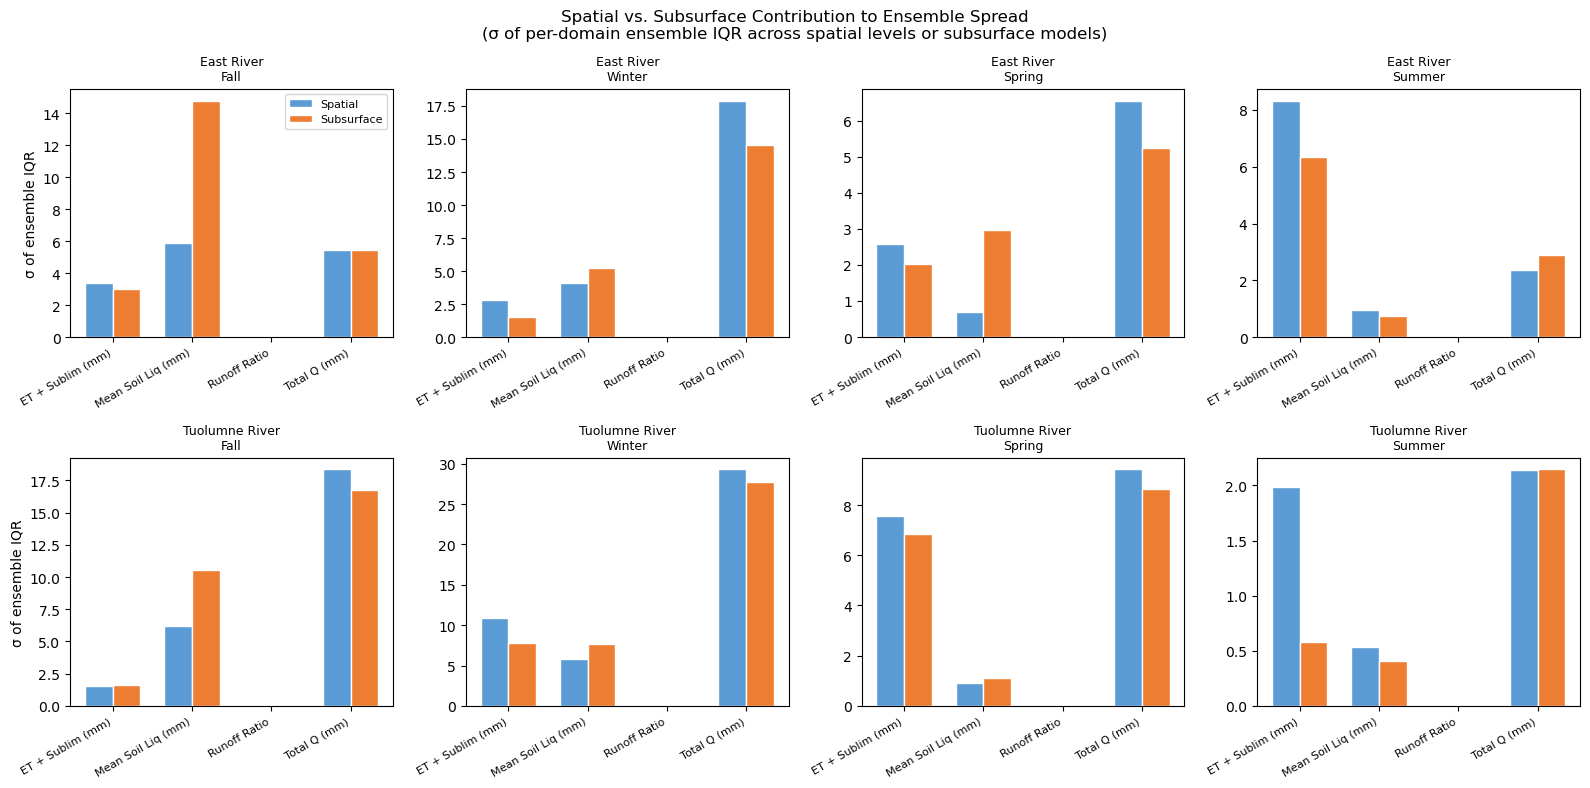

In [8]:
# Plot: σ_spatial vs. σ_subsurface for each basin × season
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)

for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, season in enumerate(SEASONS):
        ax = axes[row_i, col_i]
        sub = decomp_mean[(decomp_mean['basin'] == basin) & (decomp_mean['season'] == season)]
        pivot = sub.pivot(index='label', columns='dimension', values='sigma')
        x = np.arange(len(pivot))
        w = 0.35
        ax.bar(x - w/2, pivot.get('Spatial',    pd.Series(dtype=float)), w,
               label='Spatial', color='#5A9BD5', edgecolor='white')
        ax.bar(x + w/2, pivot.get('Subsurface', pd.Series(dtype=float)), w,
               label='Subsurface', color='#ED7D31', edgecolor='white')
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=8)
        ax.set_title(f'{basin.replace("_"," ")}\n{season.capitalize()}', fontsize=9)
        ax.set_ylabel('σ of ensemble IQR' if col_i == 0 else '')
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=8)

plt.suptitle('Spatial vs. Subsurface Contribution to Ensemble Spread\n'
             '(σ of per-domain ensemble IQR across spatial levels or subsurface models)', fontsize=12)
plt.tight_layout()
plt.show()

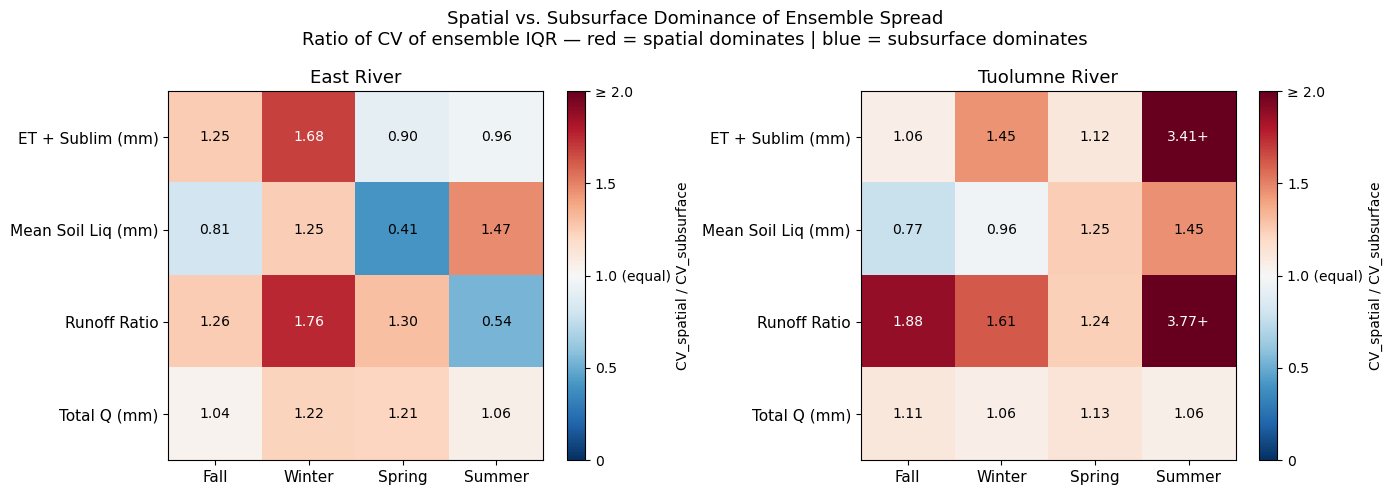

In [9]:
# Ratio of CV: CV_spatial / CV_subsurface
# CV_spatial   = std(IQR across 4 spatial levels) / mean(IQR), averaged across common models
# CV_subsurface = std(IQR across 3 subsurface models) / mean(IQR), averaged across distributed spatials
# Ratio > 1 → spatial choice drives more *relative* variability; < 1 → subsurface model does.
# Linear scale (not log), centered at 1; annotated values clipped to 3 for display.

def cv_of_group(x):
    """CV of a set of IQR values across configurations (how much does IQR vary?)."""
    x = x.dropna()
    mu = x.mean()
    return x.std() / mu if (mu > 0 and len(x) > 1) else np.nan

spatial_cv = (
    iqr_df[iqr_df['model'].isin(COMMON_MODELS)]
    .groupby(['basin', 'model', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .agg(cv_of_group)
    .reset_index()
    .melt(id_vars=['basin', 'model', 'season'], var_name='variable', value_name='cv')
    .groupby(['basin', 'season', 'variable'], observed=True)['cv']
    .mean()
    .reset_index(name='cv_spatial')
)

sub_cv = (
    iqr_df[iqr_df['spatial'].isin(DIST_SPATIALS)]
    .groupby(['basin', 'spatial', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .agg(cv_of_group)
    .reset_index()
    .melt(id_vars=['basin', 'spatial', 'season'], var_name='variable', value_name='cv')
    .groupby(['basin', 'season', 'variable'], observed=True)['cv']
    .mean()
    .reset_index(name='cv_subsurface')
)

ratio_cv = spatial_cv.merge(sub_cv, on=['basin', 'season', 'variable'])
ratio_cv['ratio'] = ratio_cv['cv_spatial'] / ratio_cv['cv_subsurface']
ratio_cv['label'] = ratio_cv['variable'].map(dict(TARGET_VARS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, basin in zip(axes, ['East_River', 'Tuolumne_River']):
    sub = ratio_cv[ratio_cv['basin'] == basin]
    pivot = sub.pivot_table(index='label', columns='season', values='ratio')[SEASONS]
    display_vals = pivot.clip(upper=3.0)
    im = ax.imshow(display_vals.values, cmap='RdBu_r', vmin=0, vmax=2, aspect='auto')
    ax.set_xticks(range(len(SEASONS)))
    ax.set_xticklabels([s.capitalize() for s in SEASONS], fontsize=11)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=11)
    ax.set_title(f'{basin.replace("_", " ")}', fontsize=13)
    for i in range(len(pivot)):
        for j in range(len(SEASONS)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                txt = f'{val:.2f}' + ('+' if val > 3.0 else '')
                bg = display_vals.values[i, j]
                ax.text(j, i, txt, ha='center', va='center', fontsize=10,
                        color='white' if abs(bg - 1) > 0.65 else 'black')
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('CV_spatial / CV_subsurface', fontsize=10)
    cb.set_ticks([0, 0.5, 1.0, 1.5, 2.0])
    cb.set_ticklabels(['0', '0.5', '1.0 (equal)', '1.5', '≥ 2.0'])

plt.suptitle('Spatial vs. Subsurface Dominance of Ensemble Spread\n'
             'Ratio of CV of ensemble IQR — red = spatial dominates | blue = subsurface dominates',
             fontsize=13)
plt.tight_layout()
plt.show()


## 5. Snow Accumulation as a Variability Signal

For fall and spring, is **positive SWE change** (net snow accumulation over the season) a strong predictor of seasonal streamflow variability? This captures the warm/cool signal more physically than temperature alone — a cool donor year accumulates snow; a warm year does not.

We also compare predictive power of `pos_swe_change_mm` against `mean_airtemp_C` and `total_p_mm`.

In [10]:
from scipy.stats import pearsonr, spearmanr

PREDICTORS = [
    ('pos_swe_change_mm', 'Positive SWE Change (mm)'),
    ('mean_airtemp_C',    'Mean Air Temp (°C)'),
    ('total_p_mm',        'Total Precip (mm)'),
]
RESPONSES = [
    ('total_q_mm',        'Total Q (mm)'),
    ('total_et_sublim_mm','ET + Sublim (mm)'),
    ('mean_soil_liq_mm',  'Mean Soil Liq (mm)'),
]

corr_rows = []
for (basin, season, model), grp in df[df['season'].isin(TRANS_SEASONS)].groupby(
        ['basin', 'season', 'model'], observed=True):
    for pred_col, pred_label in PREDICTORS:
        for resp_col, resp_label in RESPONSES:
            sub = grp[[pred_col, resp_col]].dropna()
            if len(sub) < 6:
                continue
            r_pearson,  p_pearson  = pearsonr(sub[pred_col],  sub[resp_col])
            r_spearman, p_spearman = spearmanr(sub[pred_col], sub[resp_col])
            corr_rows.append({
                'basin': basin, 'season': season, 'model': model,
                'predictor': pred_label, 'response': resp_label,
                'r_pearson': r_pearson, 'r_spearman': r_spearman,
                'p_pearson': p_pearson, 'p_spearman': p_spearman,
            })

corr_df = pd.DataFrame(corr_rows)

# Mean |Spearman r| by predictor × response — averaged across models
corr_mean = (
    corr_df.groupby(['basin', 'season', 'predictor', 'response'])['r_spearman']
    .mean().reset_index()
)
corr_mean.head()

,basin,season,predictor,response,r_spearman
0,East_River,fall,Mean Air Temp (°C),ET + Sublim (mm),0.335754
1,East_River,fall,Mean Air Temp (°C),Mean Soil Liq (mm),0.073349
2,East_River,fall,Mean Air Temp (°C),Total Q (mm),-0.065579
3,East_River,fall,Positive SWE Change (mm),ET + Sublim (mm),0.278045
4,East_River,fall,Positive SWE Change (mm),Mean Soil Liq (mm),0.449964


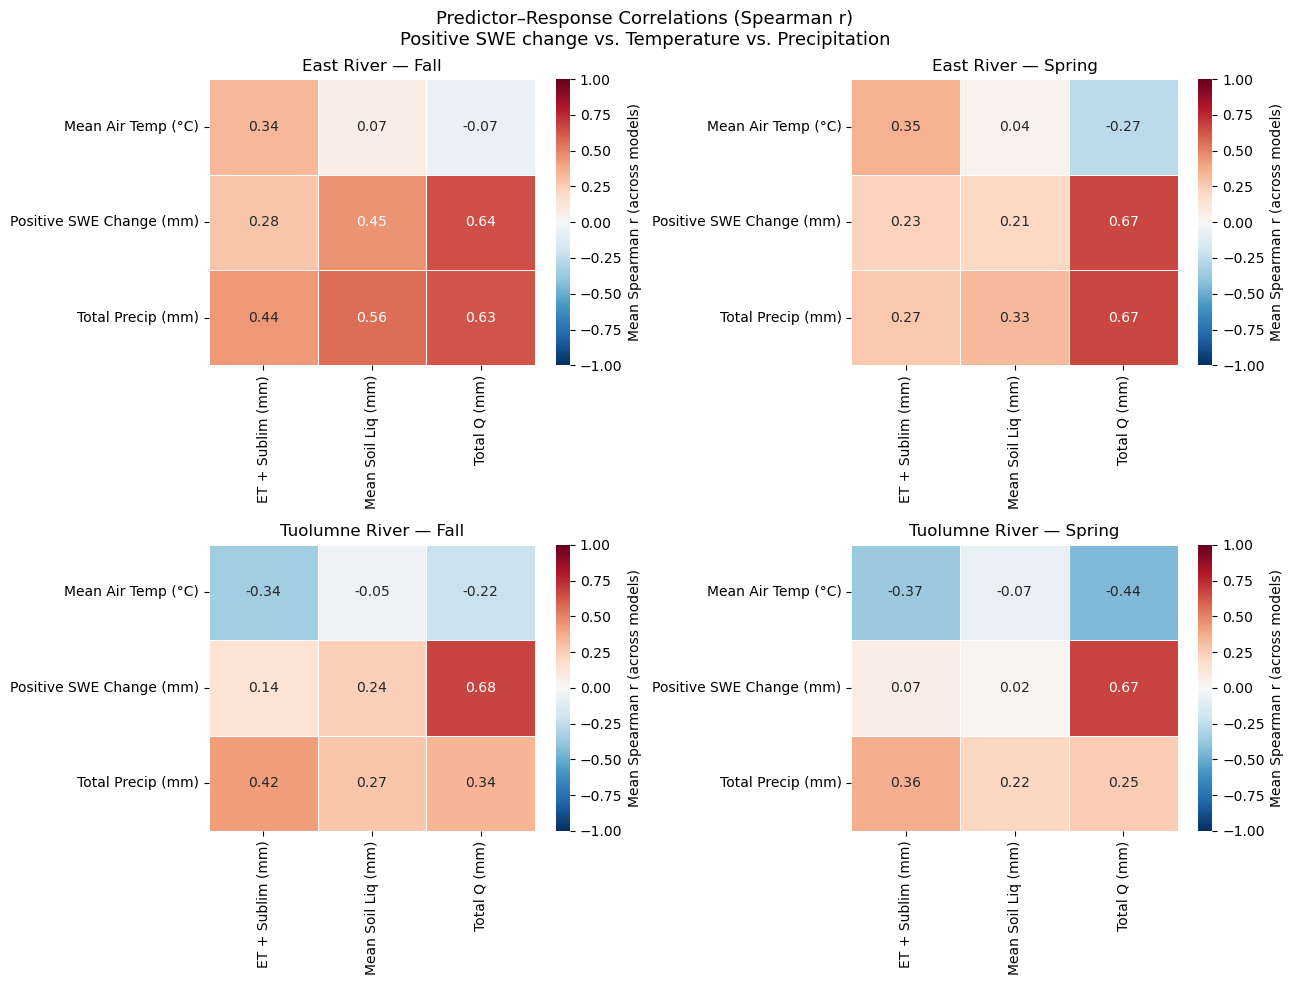

In [11]:
# Heatmap: mean Spearman r for each predictor × response, for fall and spring
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (basin, season) in zip(axes.flat, product(['East_River', 'Tuolumne_River'], TRANS_SEASONS)):
    sub = corr_mean[(corr_mean['basin'] == basin) & (corr_mean['season'] == season)]
    pivot = sub.pivot(index='predictor', columns='response', values='r_spearman')
    sns.heatmap(
        pivot, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', linewidths=0.5,
        cbar_kws={'label': 'Mean Spearman r (across models)'}
    )
    ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Predictor–Response Correlations (Spearman r)\n'
             'Positive SWE change vs. Temperature vs. Precipitation', fontsize=13)
plt.tight_layout()
plt.show()

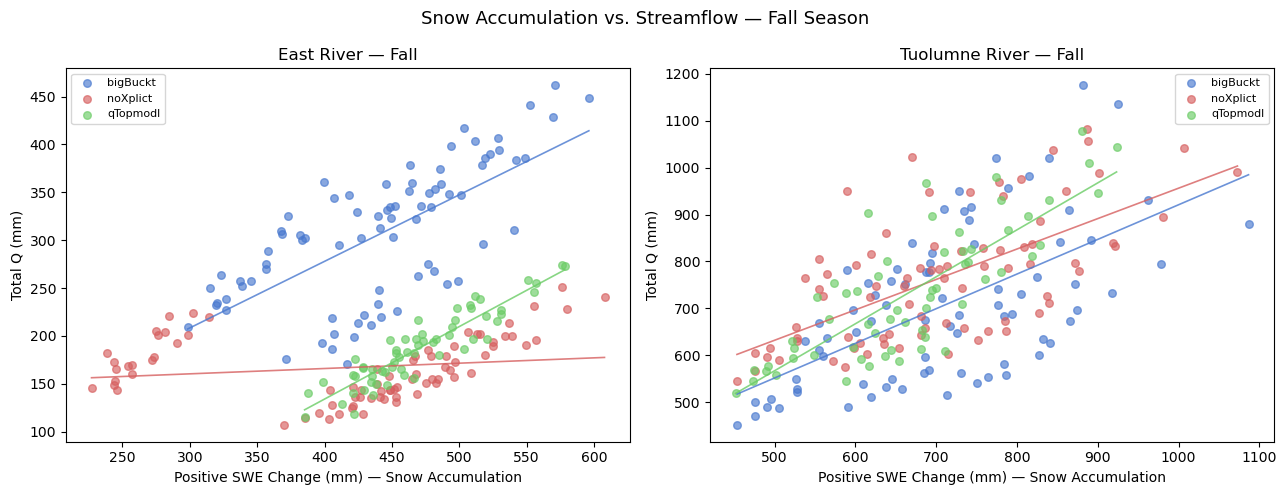

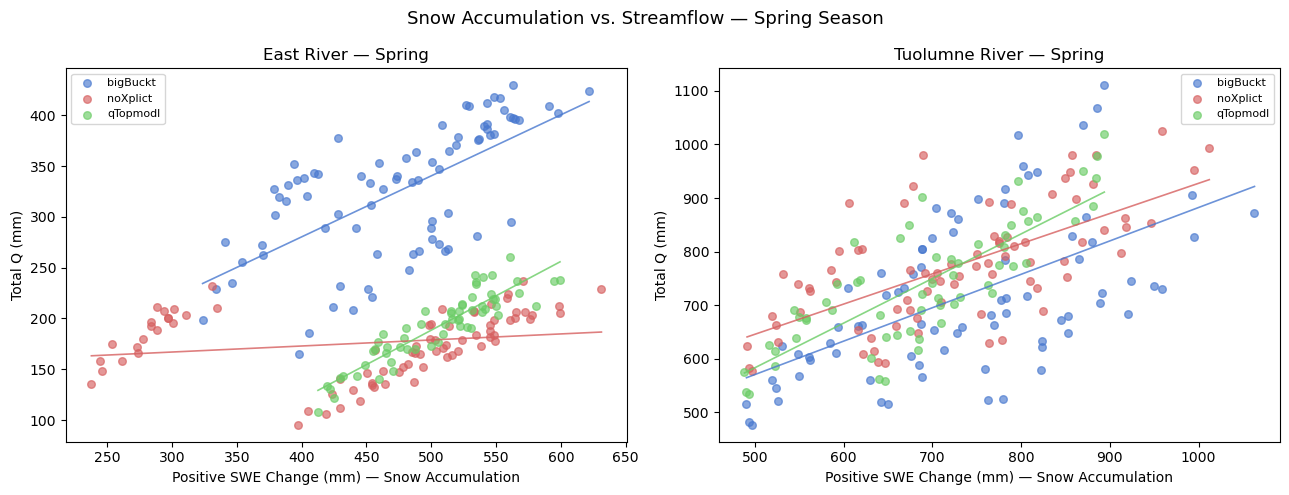

In [12]:
# Scatter: pos_swe_change_mm vs. total_q_mm for fall and spring, colored by model
for season in TRANS_SEASONS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, basin in zip(axes, ['East_River', 'Tuolumne_River']):
        sub = df[(df['basin'] == basin) & (df['season'] == season)].dropna(
            subset=['pos_swe_change_mm', 'total_q_mm'])
        for model in MODEL_ORDER:
            m = sub[sub['model'] == model]
            if m.empty:
                continue
            ax.scatter(m['pos_swe_change_mm'], m['total_q_mm'],
                       color=MODEL_COLORS[model], label=model, alpha=0.65, s=30)
            # regression line per model
            x, y = m['pos_swe_change_mm'], m['total_q_mm']
            if len(x) > 3:
                xfit = np.linspace(x.min(), x.max(), 50)
                slope, intercept, *_ = stats.linregress(x, y)
                ax.plot(xfit, slope * xfit + intercept,
                        color=MODEL_COLORS[model], lw=1.2, alpha=0.8)
        ax.set_xlabel('Positive SWE Change (mm) — Snow Accumulation')
        ax.set_ylabel('Total Q (mm)')
        ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
        ax.legend(fontsize=8)
    plt.suptitle(f'Snow Accumulation vs. Streamflow — {season.capitalize()} Season', fontsize=13)
    plt.tight_layout()
    plt.show()

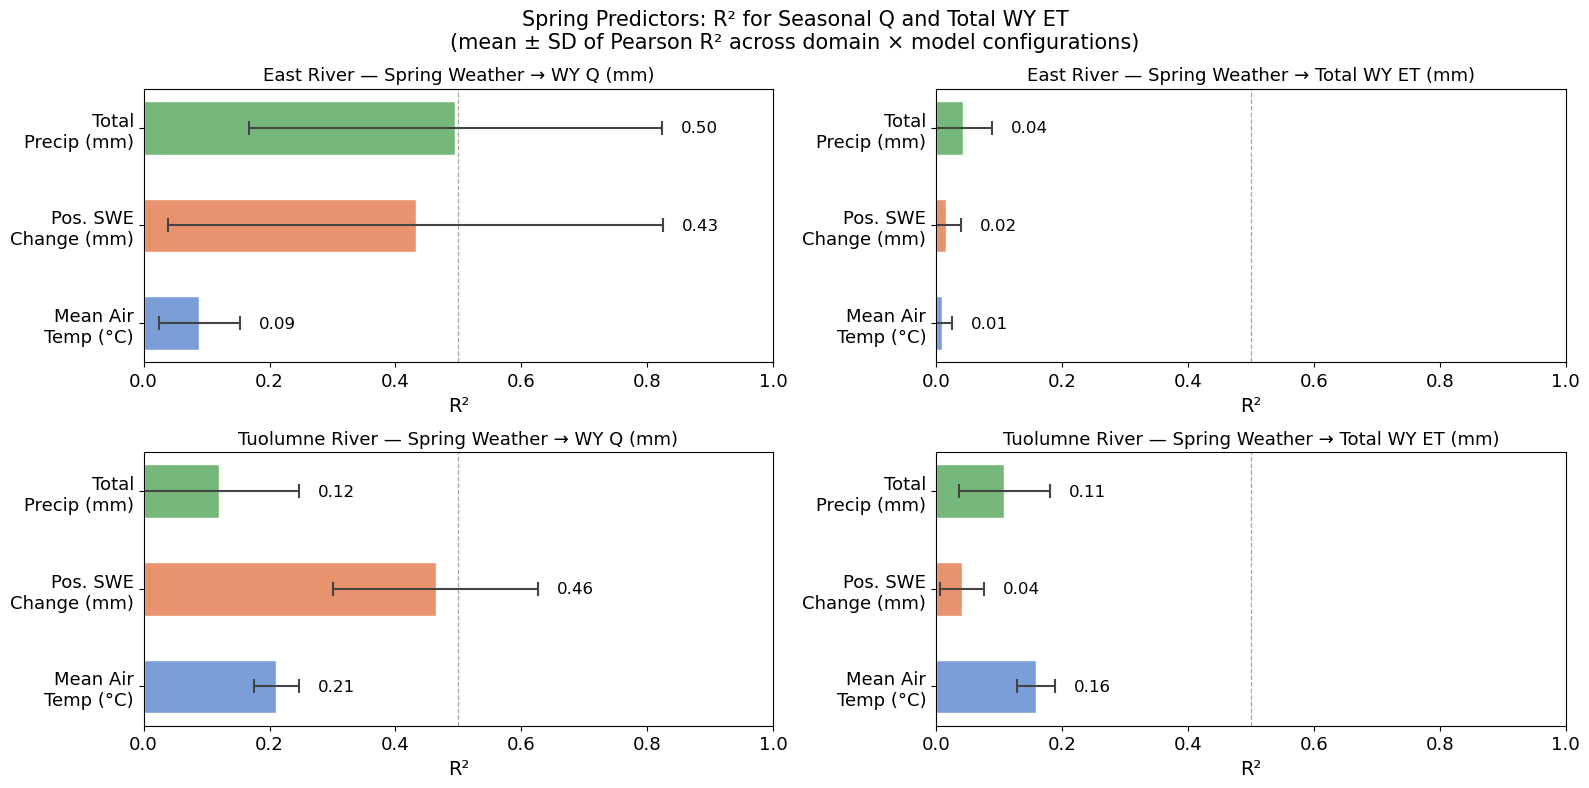

In [13]:
# ============================================================
# 7. Spring Predictors → R² for Seasonal Q and Total WY ET
# ============================================================
# "Total WY ET" = sum of total_et_sublim_mm across all 4 seasons per donor year.
# Spring predictors (SWE change, temp, precip) correlated with spring Q and WY-total ET.
# R² computed per (basin, model) combination, then mean ± std across models shown.
# Note: sublimation is included in total_et_sublim_mm but is a minor fraction.

wy_et = (
    df.groupby(['basin', 'model', 'donor_wy'], observed=True)['total_et_sublim_mm']
    .sum()
    .reset_index()
    .rename(columns={'total_et_sublim_mm': 'total_wy_et_mm'})
)

spring_wy = (
    df[df['season'] == 'spring'][[
        'basin', 'spatial', 'model', 'donor_wy',
        'pos_swe_change_mm', 'mean_airtemp_C', 'total_p_mm', 'total_q_mm'
    ]]
    .merge(wy_et, on=['basin', 'model', 'donor_wy'])
)

PREDICTORS_SP = [
    ('pos_swe_change_mm', 'Pos. SWE\nChange (mm)'),
    ('mean_airtemp_C',    'Mean Air\nTemp (°C)'),
    ('total_p_mm',        'Total\nPrecip (mm)'),
]
RESPONSES_WY = [
    ('total_q_mm',     'WY Q (mm)'),
    ('total_wy_et_mm', 'Total WY ET (mm)'),
]

# Compute r² per (basin, model) — square first, then aggregate for unbiased mean
corr_wy_rows = []
for (basin, model), grp in spring_wy.groupby(['basin', 'model'], observed=True):
    for pred_col, pred_label in PREDICTORS_SP:
        for resp_col, resp_label in RESPONSES_WY:
            sub = grp[[pred_col, resp_col]].dropna()
            if len(sub) < 6:
                continue
            r, _ = stats.pearsonr(sub[pred_col], sub[resp_col])
            corr_wy_rows.append({
                'basin': basin, 'model': model,
                'predictor': pred_label, 'response': resp_label,
                'r2': r ** 2,
            })

corr_wy_df = pd.DataFrame(corr_wy_rows)

r2_wy = (
    corr_wy_df.groupby(['basin', 'predictor', 'response'])['r2']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'R2', 'std': 'R2_std'})
)

PRED_COLORS = ['#7B9ED9', '#E8936E', '#76B77B']

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, (resp_col, resp_label) in enumerate(RESPONSES_WY):
        ax = axes[row_i, col_i]
        sub = r2_wy[(r2_wy['basin'] == basin) & (r2_wy['response'] == resp_label)]
        preds = sub['predictor'].tolist()
        vals  = sub['R2'].tolist()
        errs  = sub['R2_std'].tolist()
        bars = ax.barh(preds, vals, xerr=errs, color=PRED_COLORS[:len(preds)],
                       edgecolor='white', height=0.55,
                       error_kw=dict(ecolor='#444444', capsize=5, capthick=1.5, elinewidth=1.5))
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color='gray', lw=0.9, ls='--', alpha=0.7)
        ax.set_xlabel('R²', fontsize=14)
        ax.set_title(f'{basin.replace("_", " ")} — Spring Weather → {resp_label}', fontsize=13)
        ax.tick_params(labelsize=13)
        for bar, val, err in zip(bars, vals, errs):
            x_ann = min(val + err + 0.03, 0.93)
            ax.text(x_ann, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}', va='center', fontsize=12)

plt.suptitle('Spring Predictors: R² for Seasonal Q and Total WY ET\n'
             '(mean ± SD of Pearson R² across domain × model configurations)', fontsize=15)
plt.tight_layout()
plt.savefig('ess-project/figures/fig_spring_r2_wy_et.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import xarray as xr

# ============================================================
# 8a. Storage — SWE at Jul 31, soil liquid + aquifer at end-of-WY (Sep 30)
# ============================================================
# scalarSWE            → Jul 31 (captures residual snowpack before full melt)
# scalarTotalSoilLiq   → last timestep (Sep 30)
# scalarAquiferStorage → last timestep (Sep 30)
# Delete the cache file to force recompute.

STORAGE_CACHE = Path('ess-project/results/spring_storage_jul31swe.csv')

def _area_weighted_mean(da, hru_areas):
    vals = da.values.squeeze()
    if hru_areas is not None and "hru" in da.dims:
        w = hru_areas.values / hru_areas.values.sum()
        return float((vals * w).sum())
    return float(vals.mean())

if STORAGE_CACHE.exists():
    spring_storage_df = pd.read_csv(STORAGE_CACHE)
    print(f"Loaded storage cache: {len(spring_storage_df):,} rows")
else:
    hru_areas_cache = {}
    for domain in DOMAIN_REGISTRY:
        attr_path = DATA_DIR / f"domain_{domain}" / "settings" / "SUMMA" / "attributes.nc"
        if attr_path.exists():
            with xr.open_dataset(attr_path) as attrs:
                hru_areas_cache[domain] = attrs["HRUarea"].load()
        else:
            print(f"  Warning: attr file missing for {domain}")

    _JUL31 = "2021-08-31"

    storage_rows = []
    for domain, meta in DOMAIN_REGISTRY.items():
        ens_dir = DATA_DIR / f"domain_{domain}" / "simulations" / "seasonal_ensemble_simulations"
        hru_areas = hru_areas_cache.get(domain)
        for model in meta["models"]:
            for wy in range(2001, 2021):
                nc_path = (ens_dir / model / "spring_simulations"
                           / f"donor_{wy}" / "output"
                           / f"seasonal_spring_d{wy}_timestep.nc")
                if not nc_path.exists():
                    continue
                try:
                    with xr.open_dataset(nc_path) as ds:
                        # SWE at Jul 31 (nearest hourly timestep)
                        swe_da  = ds["scalarSWE"].sel(time=_JUL31, method="nearest") \
                                  if "scalarSWE" in ds else None
                        # Soil and aquifer at end of WY
                        soil_da = ds["scalarTotalSoilLiq"].isel(time=-1) \
                                  if "scalarTotalSoilLiq" in ds else None
                        aq_var  = next((v for v in ["scalarAquiferStorage_mean", "scalarAquiferStorage"]
                                        if v in ds), None)
                        aq_da   = ds[aq_var].isel(time=-1) if aq_var else None

                        swe_mm  = _area_weighted_mean(swe_da,  hru_areas) if swe_da  is not None else 0.0
                        soil_mm = _area_weighted_mean(soil_da, hru_areas) if soil_da is not None else 0.0
                        aq_mm   = _area_weighted_mean(aq_da,   hru_areas) * 1000 \
                                  if (aq_da is not None and model == "bigBuckt") else 0.0

                    storage_rows.append({
                        "domain": domain, "model": model, "donor_wy": wy,
                        "swe_mm": swe_mm, "soil_liq_mm": soil_mm, "aquifer_mm": aq_mm,
                        "total_storage_mm": swe_mm + soil_mm + aq_mm,
                    })
                except Exception as e:
                    print(f"  Warning: {domain}/{model}/donor_{wy}: {e}")

    spring_storage_df = pd.DataFrame(storage_rows)
    spring_storage_df["basin"]   = spring_storage_df["domain"].map({d: m["basin"]   for d, m in DOMAIN_REGISTRY.items()})
    spring_storage_df["spatial"] = spring_storage_df["domain"].map({d: m["spatial"] for d, m in DOMAIN_REGISTRY.items()})
    spring_storage_df["spatial"] = pd.Categorical(spring_storage_df["spatial"], categories=SPATIAL_ORDER, ordered=True)
    spring_storage_df["model"]   = pd.Categorical(spring_storage_df["model"],   categories=MODEL_ORDER,   ordered=True)

    STORAGE_CACHE.unlink(missing_ok=True)
    spring_storage_df.to_csv(STORAGE_CACHE, index=False)
    print(f"Storage cache written: {len(spring_storage_df):,} rows")

# Total WY Q
wy_q = (
    df.groupby(["domain", "model", "donor_wy"], observed=True)["total_q_mm"]
    .sum().reset_index().rename(columns={"total_q_mm": "total_wy_q_mm"})
)

spring_wy_s = (
    df[df["season"] == "spring"][[
        "domain", "basin", "spatial", "model", "donor_wy",
        "total_p_mm", "total_snowfall_mm", "mean_airtemp_C",
        "total_et_sublim_mm", "total_q_mm",
    ]]
    .merge(
        spring_storage_df[["domain", "model", "donor_wy",
                            "swe_mm", "soil_liq_mm", "aquifer_mm", "total_storage_mm"]],
        on=["domain", "model", "donor_wy"], how="left"
    )
    .merge(wy_q, on=["domain", "model", "donor_wy"], how="left")
)

print(spring_storage_df.groupby("model")[["swe_mm","soil_liq_mm","aquifer_mm"]].mean().round(1))
spring_storage_df.head(3)


Loaded storage cache: 440 rows
          swe_mm  soil_liq_mm  aquifer_mm
model                                    
bigBuckt     3.0        147.0        66.2
noXplict     0.2        125.1         0.0
qTopmodl     3.7        337.4         0.0


,domain,model,donor_wy,swe_mm,soil_liq_mm,aquifer_mm,total_storage_mm,basin,spatial
0,East_River_lumped,bigBuckt,2001,0.0,103.969515,133.515428,237.484943,East_River,lumped
1,East_River_lumped,bigBuckt,2002,0.0,103.969703,134.201571,238.171275,East_River,lumped
2,East_River_lumped,bigBuckt,2003,0.0,103.969547,140.291098,244.260645,East_River,lumped


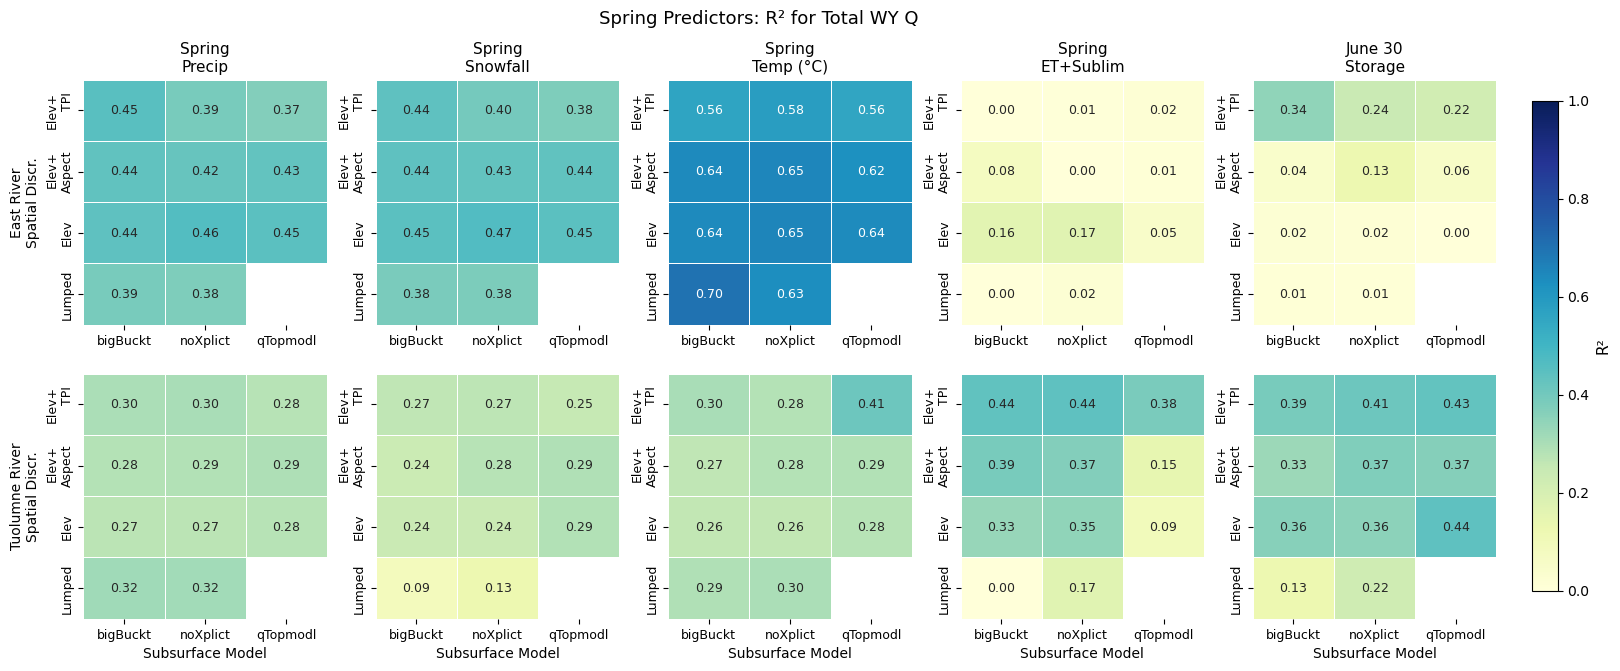

In [15]:
# ============================================================
# 8c. R² Heatmap: Spring Predictors → Total WY Q
# ============================================================
# Each cell = Pearson R² across 20 donor years for one (spatial, model) combo.
# Response = total WY Q (sum of Q across all 4 seasons per donor_wy).
# Layout: 2 rows (basins) × 5 cols (predictors).
# Within each panel: y = spatial discretization (lumped bottom → elevTPI top),
#                    x = subsurface model (bigBuckt left → qTopmodl right).

PREDICTORS_H = [
    ('total_p_mm',         'Spring\nPrecip'),
    ('total_snowfall_mm',  'Spring\nSnowfall'),
    ('mean_airtemp_C',     'Spring\nTemp (°C)'),
    ('total_et_sublim_mm', 'Spring\nET+Sublim'),
    ('total_storage_mm',   'June 30\nStorage'),
]
SPATIAL_ABBR = {
    'lumped': 'Lumped', 'elev': 'Elev',
    'elevAspect': 'Elev+\nAspect', 'elevTPI': 'Elev+\nTPI',
}

r2_heat_rows = []
for (basin, spatial, model), grp in spring_wy_s.groupby(['basin', 'spatial', 'model'], observed=True):
    for pred_col, pred_label in PREDICTORS_H:
        sub = grp[['total_wy_q_mm', pred_col]].dropna()
        if len(sub) < 6:
            continue
        r, _ = stats.pearsonr(sub[pred_col], sub['total_wy_q_mm'])
        r2_heat_rows.append({
            'basin': basin, 'spatial': spatial, 'model': model,
            'predictor': pred_label, 'r2': r ** 2,
        })

r2_heat_df = pd.DataFrame(r2_heat_rows)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, (pred_col, pred_label) in enumerate(PREDICTORS_H):
        ax = axes[row_i, col_i]
        sub = r2_heat_df[(r2_heat_df['basin'] == basin) & (r2_heat_df['predictor'] == pred_label)]
        pivot = sub.pivot_table(index='spatial', columns='model', values='r2')
        # Reverse spatial order so lumped is at bottom of heatmap (seaborn draws top→down)
        spatial_avail = [s for s in reversed(SPATIAL_ORDER) if s in pivot.index]
        model_avail   = [m for m in MODEL_ORDER if m in pivot.columns]
        pivot = pivot.reindex(index=spatial_avail, columns=model_avail)
        pivot.index = [SPATIAL_ABBR.get(s, s) for s in spatial_avail]
        sns.heatmap(pivot, ax=ax, cmap='YlGnBu', annot=True, fmt='.2f',
                    linewidths=0.5, vmin=0, vmax=1, cbar=False,
                    annot_kws={'size': 9})
        if row_i == 0:
            ax.set_title(pred_label, fontsize=11)
        ax.set_ylabel('Spatial Discr.' if col_i == 0 else '', fontsize=10)
        ax.set_xlabel('Subsurface Model' if row_i == 1 else '', fontsize=10)
        if col_i == 0:
            ax.set_ylabel(f'{basin.replace("_", " ")}\nSpatial Discr.', fontsize=10)
        ax.tick_params(labelsize=9)

# Shared colorbar
fig.subplots_adjust(right=0.91)
cbar_ax = fig.add_axes([0.93, 0.15, 0.014, 0.7])
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax).set_label('R²', fontsize=11)

plt.suptitle('Spring Predictors: R² for Total WY Q',
            #  '(Pearson R² across 20 donor years — each cell = one spatial × subsurface configuration)',
             fontsize=13)
plt.savefig('ess-project/figures/fig_spring_r2_heatmap_wyq.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:

# ============================================================
# 9. Spring Ensemble Conceptual Figure
# Top-left:  streamflow timeseries (all 20 donors; highlight 5 wettest/driest)
# Top-right: cumulative ET timeseries (same colour scheme)
# Bottom:    Jun 30 storage stacked bars ordered dry → wet
# Focus: East River elevTPI · bigBuckt, AMJ season perturbed
# ============================================================

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path

FOCUS_DOMAIN  = 'East_River_distributed_elevTPI'
FOCUS_MODEL   = 'bigBuckt'
TARGET_SEASON = 'spring'
N_EXTREME     = 5

ens_dir = DATA_DIR / f'domain_{FOCUS_DOMAIN}' / 'simulations' / 'seasonal_ensemble_simulations'

# HRU weights (for ET area-weighting)
with xr.open_dataset(DATA_DIR / f'domain_{FOCUS_DOMAIN}/settings/SUMMA/attributes.nc') as _dsa:
    _a = _dsa['HRUarea'].values.ravel().astype(float)
    BASIN_AREA = float(_a.sum())
    HRU_W = _a / _a.sum()

def _am(da):
    arr = da.values
    if arr.ndim == 2 and arr.shape[1] == len(HRU_W):
        return (arr * HRU_W[None, :]).sum(axis=1)
    return arr.mean(axis=-1) if arr.ndim > 1 else arr.ravel()

# Rank donors by spring Q (dry → wet order)
spring_rank = (
    df[(df['domain'] == FOCUS_DOMAIN) & (df['model'] == FOCUS_MODEL)
       & (df['season'] == TARGET_SEASON)]
    .sort_values('total_q_mm')
    [['donor_wy', 'total_q_mm', 'total_p_mm']]
    .reset_index(drop=True)
)
WET_SET = set(spring_rank.tail(N_EXTREME)['donor_wy'])
DRY_SET = set(spring_rank.head(N_EXTREME)['donor_wy'])
ALL_WY  = spring_rank['donor_wy'].tolist()

# WY2021 starts Oct 1, 2020
REF = pd.Timestamp('2020-10-01')
def to_doy(s):
    return pd.Series(s.values, index=(s.index - REF).days + 1)

# Load daily Q and cumulative ET for all donors
print('Loading spring ensemble timeseries...')
Q_DAY  = {}
ET_CUM = {}

for wy in ALL_WY:
    nc = (ens_dir / FOCUS_MODEL / f'{TARGET_SEASON}_simulations'
          / f'donor_{wy}' / 'output'
          / f'seasonal_{TARGET_SEASON}_d{wy}_timestep.nc')
    if not nc.exists():
        print(f'  Missing: {nc.name}')
        continue
    try:
        with xr.open_dataset(nc) as ds:
            ti = pd.DatetimeIndex(ds.time.values)
            q = (pd.Series(ds['averageRoutedRunoff'].mean(dim='gru').values.ravel() * BASIN_AREA,
                           index=ti)
                 .resample('1D').mean())
            et_arr = _am(ds['scalarTotalET']).copy()
            for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
                if v in ds:
                    et_arr += _am(ds[v])
            et_d = pd.Series(np.abs(et_arr) * 3600, index=ti).resample('1D').sum()
            Q_DAY[wy]  = to_doy(q)
            ET_CUM[wy] = to_doy(et_d.cumsum())
    except Exception as e:
        print(f'  donor_{wy}: {e}')
print(f'  Loaded {len(Q_DAY)}/{len(ALL_WY)} donors')

# Baseline (unperturbed WY2021) — try common naming conventions
Q_BASE = None; ET_BASE = None
for cand in [
    ens_dir / FOCUS_MODEL / f'{TARGET_SEASON}_simulations' / 'baseline' / 'output' / f'seasonal_{TARGET_SEASON}_baseline_timestep.nc',
    ens_dir / FOCUS_MODEL / f'{TARGET_SEASON}_simulations' / 'target_year' / 'output' / f'seasonal_{TARGET_SEASON}_target_timestep.nc',
]:
    if cand.exists():
        with xr.open_dataset(cand) as ds:
            ti = pd.DatetimeIndex(ds.time.values)
            q = (pd.Series(ds['averageRoutedRunoff'].mean(dim='gru').values.ravel() * BASIN_AREA,
                           index=ti).resample('1D').mean())
            et_arr = _am(ds['scalarTotalET']).copy()
            for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
                if v in ds:
                    et_arr += _am(ds[v])
            et_d = pd.Series(np.abs(et_arr) * 3600, index=ti).resample('1D').sum()
            Q_BASE  = to_doy(q)
            ET_BASE = to_doy(et_d.cumsum())
        print(f'  Baseline: {cand.name}')
        break
if Q_BASE is None:
    print('  No baseline file found (skipping baseline line)')

# Storage sorted dry → wet
stor_sorted = (
    spring_storage_df[(spring_storage_df['domain'] == FOCUS_DOMAIN)
                      & (spring_storage_df['model'] == FOCUS_MODEL)]
    .merge(spring_rank[['donor_wy', 'total_q_mm']], on='donor_wy')
    .sort_values('total_q_mm')
    .reset_index(drop=True)
)


Loading spring ensemble timeseries...
  Loaded 20/20 donors
  No baseline file found (skipping baseline line)


In [17]:
from glob import glob
BASIN = 'East_River'
DOMAIN = 'distributed_elevTPI'
SUBSURFACE = 'bigBuckt'
TARGET_SEASON = 'spring'

filepaths = glob(str(DATA_DIR / f'domain_{BASIN}_{DOMAIN}' / 'simulations' / 'seasonal_ensemble_simulations' / f'{SUBSURFACE}' / f'{TARGET_SEASON}_simulations' / 'donor_*' / 'output' / f'seasonal_{TARGET_SEASON}_d*_timestep.nc'))
baseline = xr.open_dataset(str(DATA_DIR / f'domain_{BASIN}_{DOMAIN}' / 'simulations' / 'best_simulations' / f'{DOMAIN}_{SUBSURFACE}_best_longterm.nc')).sel(time=slice('2020-10-01', '2021-09-30'))
# LINEAR_RESERVOIR_PARAMS = {'k_fast': 0.8641534245539414, 'k_slow': 0.47518306157180934, 'f': 1.0}
LINEAR_RESERVOIR_PARAMS = {'k_fast': 0.47522528151425714, 'k_slow': 2.4805360274754705e-05, 'f': 0.8004766558786294}
baseline_q = baseline['averageRoutedRunoff'].mean(dim='gru') * BASIN_AREA
baseline_q = baseline_q.resample(time='1D').mean()
baseline_q_linres = linear_reservoir.two_reservoir_daily(baseline_q, **LINEAR_RESERVOIR_PARAMS)

baseline_q_linres_df = pd.DataFrame({
    'q': baseline_q_linres,
},
index=pd.to_datetime(baseline_q.time.values))

In [18]:
spring_q_results = {}
spring_et_results = {}
for fp in filepaths:
    ds = xr.open_dataset(fp)
    donor_wy = int(fp.split('donor_')[1].split('/')[0])
    
    # convert q to linear reservoir routing
    q = linear_reservoir.two_reservoir_daily(
        q_in=ds.sel(time=slice('2020-10-01', '2021-09-30'))['basin__TotalRunoff'].mean(dim='gru').resample(time='1D').mean() * BASIN_AREA,
        **LINEAR_RESERVOIR_PARAMS
    )
    spring_q_results[donor_wy] = pd.DataFrame({
        'q': q,
    },index=pd.to_datetime(ds['basin__TotalRunoff'].sel(time=slice('2020-10-01', '2021-09-30')).resample(time='1D').mean().time.values))

    # cumulative ET
    et_arr = _am(ds['scalarTotalET']).copy()
    for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
        if v in ds:
            et_arr += _am(ds[v])
    et_d = pd.Series(np.abs(et_arr) * 3600, index=pd.to_datetime(ds.time.values)).resample('1D').sum()
    spring_et_results[donor_wy] = et_d.cumsum()

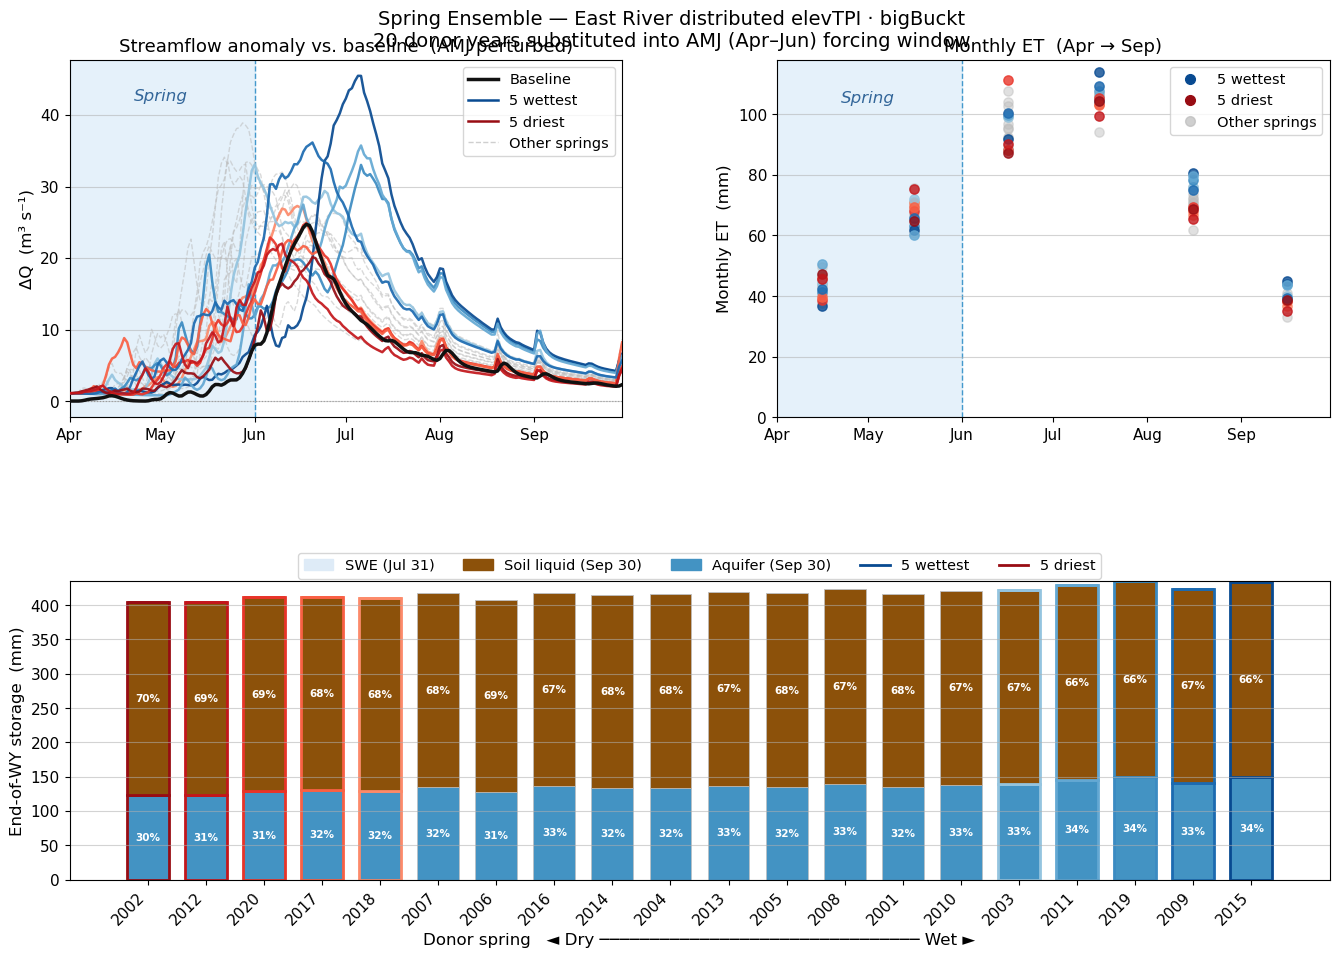

Saved → ess-project/figures/fig_spring_ensemble_combined.png


In [ ]:
# ============================================================
# 10. Spring Ensemble — Q anomaly | Monthly ET | End-of-WY Storage
# ============================================================
import matplotlib.cm as cm

FOCUS_KEY = f'{BASIN}_{DOMAIN}'

# Rank donors dry → wet
spring_rank_loc = (
    df[(df["domain"] == FOCUS_KEY) & (df["model"] == SUBSURFACE)
       & (df["season"] == TARGET_SEASON)]
    .sort_values("total_q_mm")[["donor_wy", "total_q_mm"]].reset_index(drop=True)
)
WET_N = set(spring_rank_loc.tail(N_EXTREME)["donor_wy"])
DRY_N = set(spring_rank_loc.head(N_EXTREME)["donor_wy"])
WET_LIST = spring_rank_loc[spring_rank_loc["donor_wy"].isin(WET_N)]["donor_wy"].tolist()
DRY_LIST = spring_rank_loc[spring_rank_loc["donor_wy"].isin(DRY_N)]["donor_wy"].tolist()

# Gradient blues (driest-of-wet = lightest, wettest = darkest)
# Gradient reds  (driest = darkest, least-dry = lightest)
WET_CMAP = dict(zip(WET_LIST, cm.Blues(np.linspace(0.40, 0.90, N_EXTREME))))
DRY_CMAP = dict(zip(DRY_LIST, cm.Reds( np.linspace(0.90, 0.40, N_EXTREME))))
BLUE_REP = WET_CMAP[WET_LIST[-1]]   # darkest blue for legend
RED_REP  = DRY_CMAP[DRY_LIST[0]]    # darkest red  for legend
GREY = "#bbbbbb"; BLACK = "#111111"

# Storage colours: aquifer bottom, soil middle, SWE top
COL_AQ   = "#4393c3"   # steel blue
COL_SOIL = "#8c510a"   # brown
COL_SWE  = "#deebf7"   # light blue

def _style(wy):
    """Return (color, lw, ls, zorder, alpha) for a given donor year."""
    if wy in WET_N: return WET_CMAP[wy], 1.8, "-", 4, 0.92
    if wy in DRY_N: return DRY_CMAP[wy], 1.8, "-", 4, 0.92
    return GREY, 1.0, "--", 2, 0.55

df_base_apr1 = float(baseline_q_linres_df.loc["2021-04-01"]["q"])

stor_sorted = (
    spring_storage_df[(spring_storage_df["domain"] == FOCUS_KEY)
                      & (spring_storage_df["model"] == SUBSURFACE)]
    .merge(spring_rank_loc[["donor_wy", "total_q_mm"]], on="donor_wy")
    .sort_values("total_q_mm").reset_index(drop=True)
)

# ── Date constants & shared tick labels ──────────────────────────────────
_APR1  = pd.Timestamp("2021-04-01")
_JUN1  = pd.Timestamp("2021-06-01")
_SEP30 = pd.Timestamp("2021-09-30")
SHADE  = dict(color="#cce5f7", alpha=0.50, zorder=0)
_TICKS  = [pd.Timestamp(f"2021-{m:02d}-01") for m in [4, 5, 6, 7, 8, 9]]
_LABELS = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]
GRD = dict(axis="y", lw=0.8, alpha=0.55)
FS  = dict(ti=13, ax=12, tk=11, lg=10.5, an=12)

# ── Figure ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.2, 1.0],
                        hspace=0.50, wspace=0.28,
                        left=0.07, right=0.97, top=0.92, bottom=0.10)
ax_q  = fig.add_subplot(gs[0, 0])
ax_et = fig.add_subplot(gs[0, 1])
ax_st = fig.add_subplot(gs[1, :])

# ── Q anomaly ─────────────────────────────────────────────────────────────
for wy, dq in spring_q_results.items():
    c, lw, ls, zo, al = _style(wy)
    anom = dq.loc[_APR1:]["q"] - df_base_apr1
    ax_q.plot(anom.index, anom.values, color=c, lw=lw, ls=ls, alpha=al, zorder=zo)

bl_anom = baseline_q_linres_df.loc[_APR1:_SEP30, "q"] - df_base_apr1
ax_q.plot(bl_anom.index, bl_anom.values, color=BLACK, lw=2.5, zorder=6)
ax_q.axvspan(_APR1, _JUN1, **SHADE)
ax_q.axvline(_JUN1, color="#4499cc", lw=1.0, ls="--", zorder=1)
ax_q.axhline(0, color="0.5", lw=0.8, ls=":", zorder=1)
ax_q.set_xlim(_APR1, _SEP30)
ax_q.set_xticks(_TICKS); ax_q.set_xticklabels(_LABELS, fontsize=FS["tk"])
ax_q.set_ylabel("ΔQ  (m³ s⁻¹)", fontsize=FS["ax"])
ax_q.set_title("Streamflow anomaly vs. baseline  (AMJ perturbed)", fontsize=FS["ti"])
ax_q.grid(True, **GRD); ax_q.tick_params(axis="y", labelsize=FS["tk"])
ax_q.text(pd.Timestamp("2021-05-01"), ax_q.get_ylim()[1] * 0.88, "Spring",
          ha="center", fontsize=FS["an"], color="#336699", style="italic", zorder=7)
ax_q.legend(handles=[
    mlines.Line2D([], [], color=BLACK,    lw=2.5, label="Baseline"),
    mlines.Line2D([], [], color=BLUE_REP, lw=1.8, label=f"{N_EXTREME} wettest"),
    mlines.Line2D([], [], color=RED_REP,  lw=1.8, label=f"{N_EXTREME} driest"),
    mlines.Line2D([], [], color=GREY,     lw=1.0, ls="--", alpha=0.7, label="Other springs"),
], fontsize=FS["lg"], loc="upper right", frameon=True)

# ── Monthly ET scatter ────────────────────────────────────────────────────
for wy, et_s in spring_et_results.items():
    et_mo = et_s.diff().loc[_APR1:_SEP30].resample("MS").sum()
    c, *_ = _style(wy)
    al = 0.80 if (wy in WET_N or wy in DRY_N) else 0.45
    ax_et.scatter(et_mo.index + pd.Timedelta(days=15), et_mo.values,
                  color=c, s=45, alpha=al, zorder=4 if (wy in WET_N or wy in DRY_N) else 2)

ax_et.axvspan(_APR1, _JUN1, **SHADE)
ax_et.axvline(_JUN1, color="#4499cc", lw=1.0, ls="--", zorder=1)
ax_et.set_xlim(_APR1, _SEP30)
ax_et.set_xticks(_TICKS); ax_et.set_xticklabels(_LABELS, fontsize=FS["tk"])
ax_et.set_ylim(bottom=0)
ax_et.set_ylabel("Monthly ET  (mm)", fontsize=FS["ax"])
ax_et.set_title("Monthly ET  (Apr → Sep)", fontsize=FS["ti"])
ax_et.grid(True, **GRD); ax_et.tick_params(axis="y", labelsize=FS["tk"])
ax_et.text(pd.Timestamp("2021-05-01"), ax_et.get_ylim()[1] * 0.88, "Spring",
           ha="center", fontsize=FS["an"], color="#336699", style="italic", zorder=7)
ax_et.legend(handles=[
    mlines.Line2D([], [], color=BLUE_REP, lw=0, marker="o", ms=7, label=f"{N_EXTREME} wettest"),
    mlines.Line2D([], [], color=RED_REP,  lw=0, marker="o", ms=7, label=f"{N_EXTREME} driest"),
    mlines.Line2D([], [], color=GREY,     lw=0, marker="o", ms=7, alpha=0.7, label="Other springs"),
], fontsize=FS["lg"], loc="upper right", frameon=True)

# ── Stacked storage bars: aquifer | soil | SWE (dry → wet) ───────────────
n = len(stor_sorted); x = np.arange(n); BAR_W = 0.72
aq   = stor_sorted["aquifer_mm"].values
soil = stor_sorted["soil_liq_mm"].values
swe  = stor_sorted["swe_mm"].values
total_safe = np.where(aq + soil + swe == 0, 1.0, aq + soil + swe)
aq_pct   = aq   / total_safe * 100
soil_pct = soil / total_safe * 100
swe_pct  = swe  / total_safe * 100
PCT_MIN  = 5.0

for i, wy in enumerate(stor_sorted["donor_wy"]):
    ec = WET_CMAP[wy] if wy in WET_N else DRY_CMAP[wy] if wy in DRY_N else "0.75"
    ew = 2.0 if (wy in WET_N or wy in DRY_N) else 0.5
    ax_st.bar(x[i], aq[i],   BAR_W, color=COL_AQ,   edgecolor=ec, lw=ew)
    ax_st.bar(x[i], soil[i], BAR_W, color=COL_SOIL, edgecolor=ec, lw=ew, bottom=aq[i])
    ax_st.bar(x[i], swe[i],  BAR_W, color=COL_SWE,  edgecolor=ec, lw=ew, bottom=aq[i]+soil[i])
    txt = dict(ha="center", va="center", fontsize=7.5, fontweight="bold", clip_on=True)
    if aq_pct[i]   >= PCT_MIN: ax_st.text(x[i], aq[i]/2,                    f"{aq_pct[i]:.0f}%",   color="white", **txt)
    if soil_pct[i] >= PCT_MIN: ax_st.text(x[i], aq[i]+soil[i]/2,             f"{soil_pct[i]:.0f}%", color="white", **txt)
    if swe_pct[i]  >= PCT_MIN: ax_st.text(x[i], aq[i]+soil[i]+swe[i]/2,      f"{swe_pct[i]:.0f}%",  color="#2c5f8a", **txt)

ax_st.set_xticks(x)
ax_st.set_xticklabels(stor_sorted["donor_wy"].astype(str).values, rotation=45, ha="right", fontsize=FS["tk"])
ax_st.set_ylabel("End-of-WY storage  (mm)", fontsize=FS["ax"])
ax_st.set_xlabel("Donor spring   ◄ Dry ──────────────────────────────── Wet ►", fontsize=FS["ax"])
ax_st.grid(True, **GRD); ax_st.tick_params(axis="y", labelsize=FS["tk"])
ax_st.legend(handles=[
    mpatches.Patch(color=COL_SWE,  label="SWE (Jul 31)"),
    mpatches.Patch(color=COL_SOIL, label="Soil liquid (Sep 30)"),
    mpatches.Patch(color=COL_AQ,   label="Aquifer (Sep 30)"),
    mlines.Line2D([], [], color=BLUE_REP, lw=2, label=f"{N_EXTREME} wettest"),
    mlines.Line2D([], [], color=RED_REP,  lw=2, label=f"{N_EXTREME} driest"),
], fontsize=FS["lg"], loc="upper center", frameon=True, ncol=5, bbox_to_anchor=(0.5, 1.12))


out = Path("ess-project/figures/fig_spring_ensemble_combined.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

In [20]:
# ============================================================
# 11. Spring Ensemble Summary Table
# Columns: spring P (+ delta vs mean), total WY Q, Q center-of-mass DOY,
#          total WY ET, Jul-31 SWE, Sep-30 soil, Sep-30 aquifer, total storage
# Rows sorted dry → wet by spring Q; wettest 5 = blue, driest 5 = red.
# ============================================================

_REF_DATE = pd.Timestamp("2020-10-01")   # WY2021 start

rows = []
for _, r in spring_rank_loc.iterrows():
    wy = int(r["donor_wy"])
    d = {"Donor WY": wy}

    # Spring precip from summary df
    sp = df[(df["domain"] == FOCUS_KEY) & (df["model"] == SUBSURFACE)
            & (df["season"] == TARGET_SEASON) & (df["donor_wy"] == wy)]
    d["Spring P (mm)"] = round(float(sp["total_p_mm"].iloc[0]), 1) if len(sp) else np.nan

    # WY Q volume and center-of-mass timing
    if wy in spring_q_results:
        q = spring_q_results[wy]["q"]
        d["Total WY Q (mm)"] = round(float(q.sum() * 86400 / BASIN_AREA * 1000), 1)
        doy_arr = ((q.index - _REF_DATE).days + 1).values.astype(float)
        d["Q CoM DOY"] = int(round((q.values * doy_arr).sum() / q.values.sum()))
    else:
        d["Total WY Q (mm)"] = np.nan
        d["Q CoM DOY"] = np.nan

    # Total WY ET (last value of cumulative series)
    if wy in spring_et_results:
        d["Total WY ET (mm)"] = round(float(spring_et_results[wy].iloc[-1]), 1)
    else:
        d["Total WY ET (mm)"] = np.nan

    # Storage components
    st = stor_sorted[stor_sorted["donor_wy"] == wy]
    if len(st):
        d["SWE Jul31 (mm)"]    = round(float(st["swe_mm"].iloc[0]),      1)
        d["Soil Sep30 (mm)"]   = round(float(st["soil_liq_mm"].iloc[0]), 1)
        d["Aq Sep30 (mm)"]     = round(float(st["aquifer_mm"].iloc[0]),  1)
        d["Total stor (mm)"]   = round(float(st["swe_mm"].iloc[0]
                                             + st["soil_liq_mm"].iloc[0]
                                             + st["aquifer_mm"].iloc[0]), 1)
    else:
        d["SWE Jul31 (mm)"] = d["Soil Sep30 (mm)"] = d["Aq Sep30 (mm)"] = d["Total stor (mm)"] = np.nan

    rows.append(d)

summary_df = pd.DataFrame(rows).set_index("Donor WY")

# ΔP vs cross-donor mean
mean_p = summary_df["Spring P (mm)"].mean()
col_idx = summary_df.columns.get_loc("Spring P (mm)") + 1
summary_df.insert(col_idx, "ΔP vs mean", (summary_df["Spring P (mm)"] - mean_p).round(1))

# DOY → approx calendar date label column
summary_df.insert(
    summary_df.columns.get_loc("Q CoM DOY") + 1,
    "CoM date",
    summary_df["Q CoM DOY"].apply(
        lambda d: (_REF_DATE + pd.Timedelta(days=int(d) - 1)).strftime("%b %d")
        if pd.notna(d) else ""
    )
)

# ── Style ──────────────────────────────────────────────────────────────────
def _row_bg(row):
    wy = row.name
    if wy in WET_N: return ["background-color: #d6e8f7"] * len(row)
    if wy in DRY_N: return ["background-color: #fde0d4"] * len(row)
    return [""] * len(row)

styled = (
    summary_df.style
    .apply(_row_bg, axis=1)
    .format({
        "Spring P (mm)":  "{:.1f}",
        "ΔP vs mean":     "{:+.1f}",
        "Total WY Q (mm)": "{:.1f}",
        "Q CoM DOY":      "{:.0f}",
        "Total WY ET (mm)": "{:.1f}",
        "SWE Jul31 (mm)": "{:.1f}",
        "Soil Sep30 (mm)": "{:.1f}",
        "Aq Sep30 (mm)":  "{:.1f}",
        "Total stor (mm)": "{:.1f}",
    })
    .set_caption(
        f"Spring Ensemble Summary — {BASIN.replace('_',' ')} {DOMAIN.replace('_',' ')} · {SUBSURFACE}  "
        f"| Blue = {N_EXTREME} wettest | Red = {N_EXTREME} driest | Sorted dry → wet"
    )
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","12px"),("font-weight","bold"),("caption-side","top"),("text-align","left"),("padding-bottom","6px")]},
        {"selector": "th",      "props": [("font-size","10.5px"),("text-align","center"),("padding","3px 6px")]},
        {"selector": "td",      "props": [("font-size","10.5px"),("text-align","right"), ("padding","3px 8px")]},
    ])
)
display(styled)

# Quick range printout for each column
print("\nColumn ranges (min → max):")
num_cols = [c for c in summary_df.columns if summary_df[c].dtype != object]
for col in num_cols:
    lo, hi = summary_df[col].min(), summary_df[col].max()
    print(f"  {col:<22s}: {lo:8.1f} → {hi:.1f}")


,Spring P (mm),ΔP vs mean,Total WY Q (mm),Q CoM DOY,CoM date,Total WY ET (mm),SWE Jul31 (mm),Soil Sep30 (mm),Aq Sep30 (mm),Total stor (mm)
Donor WY,,,,,,,,,,
2002,740.6,-134.7,285.0,169,Mar 18,607.5,0.0,282.0,122.6,404.6
2012,757.5,-117.8,299.2,170,Mar 19,608.1,0.0,280.6,123.5,404.1
2020,821.9,-53.4,323.3,179,Mar 28,627.7,0.0,282.0,129.3,411.3
2017,799.6,-75.7,329.0,179,Mar 28,603.5,0.0,280.5,130.9,411.4
2018,820.4,-54.9,330.1,181,Mar 30,620.2,0.0,281.1,129.6,410.7
2007,832.3,-43.0,332.8,186,Apr 04,618.3,0.0,283.9,134.3,418.2
2006,825.0,-50.3,348.8,178,Mar 27,597.3,0.0,280.2,127.6,407.8
2016,869.4,-5.9,360.1,190,Apr 08,624.2,0.0,281.4,136.4,417.8
2014,863.2,-12.1,360.7,186,Apr 04,610.8,0.0,281.7,133.8,415.5



Column ranges (min → max):
  Spring P (mm)         :    740.6 → 957.4
  ΔP vs mean            :   -134.7 → 82.1
  Total WY Q (mm)       :    285.0 → 408.4
  Q CoM DOY             :    169.0 → 208.0
  Total WY ET (mm)      :    597.3 → 637.6
  SWE Jul31 (mm)        :      0.0 → 0.0
  Soil Sep30 (mm)       :    280.2 → 285.6
  Aq Sep30 (mm)         :    122.6 → 149.3
  Total stor (mm)       :    404.1 → 434.7
